In [2]:
import numpy as np
import pandas as pd


def implement_market_structure_states_strict(df, n=5):
    """Calcule les états du marché avec transition obligatoire par l'état NEUTRAL.

    Aucun passage direct entre BULLISH et BEARISH n'est autorisé.
    """
    df = df.copy()
    length = len(df)

    df['is_swing_high'] = False
    df['is_swing_low'] = False
    for k in range(n, len(df) - n):
        # Le plus haut des n bougies précédentes et suivantes
        high_range = df['High'].iloc[k - n:k + n + 1]
        if df['High'].iloc[k] == high_range.max():
            df.loc[df.index[k], 'is_swing_high'] = True
            
        # Le plus bas des n bougies précédentes et suivantes
        low_range = df['Low'].iloc[k - n:k + n + 1]
        if df['Low'].iloc[k] == low_range.min():
            df.loc[df.index[k], 'is_swing_low'] = True

    states = []
    current_state = "NEUTRAL"

    # Variables de structure de marché
    last_confirmed_high = None
    last_confirmed_low = None
    higher_low = None  # Le plancher (uniquement actif en BULLISH)
    lower_high = None  # Le plafond (uniquement actif en BEARISH)

    for j in range(length):
        close_p = df["Close"].iloc[j]

        # --- ÉTAPE B : Machine à états avec transit strict par NEUTRAL ---
        if current_state == "BULLISH":
            # Sortie de Bullish : Clôture sous le Higher Low (HL) -> NEUTRAL uniquement
            if higher_low is not None and close_p < higher_low:
                current_state = "NEUTRAL"
                last_confirmed_high = None
                last_confirmed_low = None
                higher_low = None  # Reset des repères obsolètes
                lower_high = None

        elif current_state == "BEARISH":
            # Sortie de Bearish : Clôture au-dessus du Lower High (LH) -> NEUTRAL uniquement
            if lower_high is not None and close_p > lower_high:
                current_state = "NEUTRAL"
                last_confirmed_high = None
                last_confirmed_low = None
                higher_low = None
                lower_high = None  # Reset des repères obsolètes

        elif current_state == "NEUTRAL":
            # En zone neutre, on attend un NOUVEAU BOS pour définir la tendance
            # Entrée en Bullish : Clôture au-dessus du dernier sommet confirmé
            # il faut tjs un high and un low avant de former une structure bearish ou bullish
            if last_confirmed_high is not None and last_confirmed_low is not None and close_p > last_confirmed_high:
                current_state = "BULLISH"
                higher_low = (
                    last_confirmed_low  # On fige le dernier creux comme HL
                )

            # Entrée en Bearish : Clôture sous le dernier creux confirmé
            elif last_confirmed_high is not None and last_confirmed_low is not None and close_p < last_confirmed_low:
                current_state = "BEARISH"
                lower_high = (
                    last_confirmed_high  # On fige le dernier sommet comme LH
                )

        states.append(current_state)

         # --- ÉTAPE A : Enregistrement des Swings dès qu'ils se confirment ---
        if df["is_swing_high"].iloc[j] == True:
            last_confirmed_high = df["High"].iloc[j]
            if current_state == "BEARISH" and lower_high > last_confirmed_high:
                lower_high = last_confirmed_high

        if df["is_swing_low"].iloc[j] == True:
            last_confirmed_low = df["Low"].iloc[j]
            if current_state == "BULLISH" and higher_low < last_confirmed_low:
                higher_low = last_confirmed_low

    df["market_state"] = states
    return df


In [3]:
import pandas as pd
import time

from ta.volatility import AverageTrueRange
from backtesting import Backtest, Strategy

global_range_to_consider = 0
global_tp_multiple = 0
global_stop_trade_hour = 0
global_close_range_hour = 0

class OpeningRangeBreakout(Strategy):
    # variables
    range_to_consider = 3
    tp_multiple = 5.5
    stop_trade_hour = 18
    close_range_hour = 8

    # fixed variables
    risk_percent = 0.01
    max_leverage = 4
    my_equity = 10000
    open_range_hour = close_range_hour - range_to_consider

    # def init(self, range_to_consider, tp_multiple, stop_trade_hour, close_range_hour):
    def init(self):
        self.current_day = None
        self.opening_range_high = None
        self.opening_range_low = None
        if global_range_to_consider != 0:
            self.range_to_consider = global_range_to_consider

        if global_tp_multiple != 0:
            self.tp_multiple = global_tp_multiple

        if global_stop_trade_hour != 0:
            self.stop_trade_hour = global_stop_trade_hour

        if global_close_range_hour != 0:
            self.close_range_hour = global_close_range_hour

        if global_close_range_hour != 0 and global_range_to_consider != 0:
            self.open_range_hour = global_close_range_hour - global_range_to_consider

    def reset_range(self, day):
        self.current_day = day
        self.current_day_position_taked = False
        self.opening_range_high = None
        self.opening_range_low = None

    def get_position_size(self, entry_price: float, stop_price : float) -> int:
        per_share_risk = abs(entry_price - stop_price)
        print(per_share_risk)
        if per_share_risk == 0:
            return 0

        share_by_risk = (self.risk_percent * self.equity) / entry_price

        share_by_leverage = (self.max_leverage * self.equity) / entry_price
        print(f"share_by_risk = {share_by_risk} & share_by_leverage = {share_by_leverage}")

        return int(min(share_by_risk, share_by_leverage))

    def next(self):
        t = self.data.index[-1]
        current_bar_date = self.data.index[-1].date()

        if (self.current_day != current_bar_date):
            self.reset_range(current_bar_date)
            # print(f"new date {current_bar_date}")

        if self.open_range_hour < t.time().hour and t.time().hour <= self.close_range_hour:
            if self.opening_range_high is not None:
                self.opening_range_high = max(self.opening_range_high, self.data.High[-1])
            else:
                self.opening_range_high = self.data.High[-1]

            if self.opening_range_low is not None:
                    self.opening_range_low = min(self.opening_range_low, self.data.Low[-1])
            else:
                self.opening_range_low = self.data.Low[-1]

            if t.time().hour < self.close_range_hour:
                return

        if t.time().hour > self.close_range_hour and self.opening_range_high is not None and self.opening_range_low is not None:
            c_long = self.data.Open[-1] < self.opening_range_high and self.data.Close[-1] > self.opening_range_high and self.data['market_state'] == 'BULLISH'
            c_short = self.data.Open[-1] > self.opening_range_low and self.data.Close[-1] < self.opening_range_low and self.data['market_state'] == 'BEARISH'
            
            c2 = (self.opening_range_high - self.opening_range_low) < self.data['ATR'][-1] * 2.5
            c3 = (self.opening_range_high - self.opening_range_low) > self.data['ATR'][-1] * 1.0
            c4 = t.time().hour < self.stop_trade_hour

            if not self.current_day_position_taked:
                if c_long and c2 and c3 and c4:
                    planned_entry_price = self.data.Close[-1]
                    sl_price = self.opening_range_low
                    per_share_risk = abs(planned_entry_price - sl_price)
                    tp_price = planned_entry_price + per_share_risk * self.tp_multiple
                    position_size = int((self.risk_percent * self.equity) / per_share_risk)

                    # print(f'Go long tp = {tp_price} sl = {sl_price} position size = {position_size}')
                    order = self.buy(size = position_size, tp=tp_price, sl=sl_price)
                    self.current_day_position_taked = True
                if c_short and c2 and c3 and c4:
                    planned_entry_price = self.data.Close[-1]
                    sl_price = self.opening_range_high
                    per_share_risk = abs(planned_entry_price - sl_price)
                    tp_price = planned_entry_price - per_share_risk * self.tp_multiple
                    position_size = int((self.risk_percent * self.equity) / per_share_risk)

                    # print(f'Go short tp = {tp_price} sl = {sl_price} position size = {position_size}')
                    order = self.sell(size = position_size, tp=tp_price, sl=sl_price)
                    self.current_day_position_taked = True

In [67]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from ta.trend import EMAIndicator
from ta.volatility import AverageTrueRange
from backtesting import Backtest, Strategy

window = 2
global_range_to_consider = 3
global_close_range_hour = 7
global_stop_trade_hour = 18
global_tp_multiple = 5

start_date = '2026-4-14 00:00'
end_date = '2026-9-16 00:00'
pair = 'GBPJPY'
timezone = "Europe/London"

df_d1 = pd.read_csv(f"./Trading Data/{pair}_D1.csv",sep=',', parse_dates=['Date'], index_col='Date')
df_d1 = df_d1.loc[start_date : end_date]

df_result = implement_market_structure_states_strict(df_d1, n=window)

# df['market_state'] = df_result["market_state"]

df_h1 = pd.read_csv(f"./Trading Data/{pair}_H1.csv",sep=',', parse_dates=['Date'], index_col='Date')
df_h1 = df_h1.loc[start_date : end_date]

d1_tf_direction_list = []

for index, row in df_result.iterrows():
    df_by_day = df_h1.loc[f'{index.date()}' : f'{index.date()}']
    for index2, row2 in df_by_day.iterrows():
        d1_tf_direction_list.append(row['market_state'])

df_h1['market_state'] = d1_tf_direction_list

indicator_atr_14 = AverageTrueRange(df_h1['High'], df_h1['Low'], df_h1['Close'], window=14)
df_h1['ATR'] = indicator_atr_14._atr
df_h1.index = pd.to_datetime(df_h1.index, utc=True).tz_convert(timezone)

bt = Backtest(df_h1, OpeningRangeBreakout, margin=0.02, finalize_trades=True)

stats = bt.run()

print(stats)

# plt.plot(stats._equity_curve.index, stats._equity_curve['DrawdownPct'])

bt.plot()


Start                     2026-04-14 01:00...
End                       2026-09-16 01:00...
Duration                    155 days 00:00:00
Exposure Time [%]                      44.803
Equity Final [$]                     8085.272
Equity Peak [$]                       10287.2
Return [%]                          -19.14728
Buy & Hold Return [%]                -2.71503
Return (Ann.) [%]                   -33.14935
Volatility (Ann.) [%]                14.61927
CAGR [%]                            -39.39801
Sharpe Ratio                         -2.26751
Sortino Ratio                        -1.91144
Calmar Ratio                         -1.51361
Alpha [%]                           -16.41819
Beta                                  1.00518
Max. Drawdown [%]                   -21.90086
Avg. Drawdown [%]                    -4.62595
Max. Drawdown Duration      121 days 03:00:00
Avg. Drawdown Duration       24 days 20:00:00
# Trades                                   28
Win Rate [%]                      

c:\Users\kyanh\AppData\Local\Programs\Python\Python313-arm64\Lib\site-packages\bokeh\util\serialization.py:256: UserWarning: no explicit representation of timezones available for np.datetime64
  return convert(array.astype("datetime64[us]"))


GridPlot(id='p6648', ...)

In [35]:
import pandas as pd
import numpy as np
import time

from ta.trend import EMAIndicator
from ta.volatility import AverageTrueRange
from backtesting import Backtest, Strategy

start_date = '2020-01-01 00:00'
end_date = '2026-9-17 00:00'
pair = 'USDCAD'
timezone = "America/New_York"

df_d1 = pd.read_csv(f"./Trading Data/{pair}_D1.csv",sep=',', parse_dates=['Date'], index_col='Date')
df_d1 = df_d1.loc[start_date : end_date]

df_h1 = pd.read_csv(f"./Trading Data/{pair}_H1.csv",sep=',', parse_dates=['Date'], index_col='Date')
df_h1 = df_h1.loc[start_date : end_date]

indicator_atr_14 = AverageTrueRange(df_h1['High'], df_h1['Low'], df_h1['Close'], window=14)
df_h1['ATR'] = indicator_atr_14._atr

d1_window_list = [1,2,3,4]
range_to_consider_list = [3,4,5]
close_range_hour_list = [7,8,9]
stop_trade_hour_list = [18,19,20,21]
tp_multiple_list = [1,2,3,4,5,6,7,8]

with open(f"./results/result_{pair}_{time.time()}.csv", "a") as f:
    f.write(f"Window,RTC,CRH,STH,TpMultiple,Return,ReturnYearly,MDrawdown,WinRate,NumTrades\n")

    for window in d1_window_list:
        df_h1_test = df_h1.copy()
        df_result = implement_market_structure_states_strict(df_d1, n=window)

        d1_tf_direction_list = []

        for index, row in df_result.iterrows():
            df_by_day = df_h1_test.loc[f'{index.date()}' : f'{index.date()}']
            for index2, row2 in df_by_day.iterrows():
                d1_tf_direction_list.append(row['market_state'])
        
        df_h1_test['market_state'] = d1_tf_direction_list
        df_h1_test.index = pd.to_datetime(df_h1_test.index, utc=True).tz_convert(timezone)

        for range_to_consider in range_to_consider_list:
            for close_range_hour in close_range_hour_list:
                for stop_trade_hour in stop_trade_hour_list:
                    for tp_multiple in tp_multiple_list:
                        # range_to_consider, tp_multiple, stop_trade_hour, close_range_hour
                        global_range_to_consider = range_to_consider
                        global_close_range_hour = close_range_hour
                        global_stop_trade_hour = stop_trade_hour
                        global_tp_multiple = tp_multiple

                        bt = Backtest(df_h1_test, OpeningRangeBreakout, margin=0.02, finalize_trades=True)
                        stats = bt.run()

                        f.write(f"{window},{range_to_consider},{close_range_hour},{stop_trade_hour},{tp_multiple},{stats['Return [%]']},{stats['Return (Ann.) [%]']},{stats['Max. Drawdown [%]']},{stats['Win Rate [%]']}, {stats['# Trades']}\n")

                        print(f"d1 window = {window} & range to consider = {range_to_consider} & close range hour = {close_range_hour} & stop_trade_hour = {stop_trade_hour} & tp_multiple = {tp_multiple} DONE")



d1 window = 1 & range to consider = 3 & close range hour = 7 & stop_trade_hour = 18 & tp_multiple = 1 DONE
d1 window = 1 & range to consider = 3 & close range hour = 7 & stop_trade_hour = 18 & tp_multiple = 2 DONE
d1 window = 1 & range to consider = 3 & close range hour = 7 & stop_trade_hour = 18 & tp_multiple = 3 DONE
d1 window = 1 & range to consider = 3 & close range hour = 7 & stop_trade_hour = 18 & tp_multiple = 4 DONE
d1 window = 1 & range to consider = 3 & close range hour = 7 & stop_trade_hour = 18 & tp_multiple = 5 DONE
d1 window = 1 & range to consider = 3 & close range hour = 7 & stop_trade_hour = 18 & tp_multiple = 6 DONE
d1 window = 1 & range to consider = 3 & close range hour = 7 & stop_trade_hour = 18 & tp_multiple = 7 DONE
d1 window = 1 & range to consider = 3 & close range hour = 7 & stop_trade_hour = 18 & tp_multiple = 8 DONE
d1 window = 1 & range to consider = 3 & close range hour = 7 & stop_trade_hour = 19 & tp_multiple = 1 DONE
d1 window = 1 & range to consider = 3

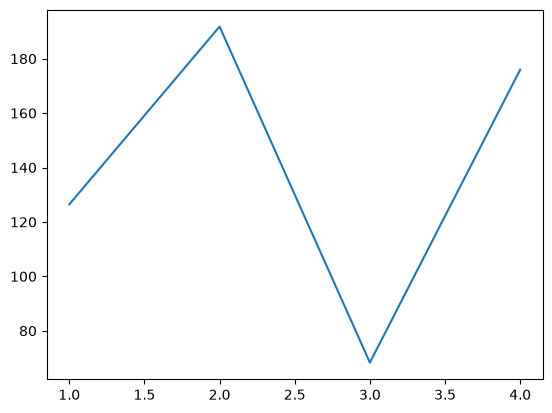

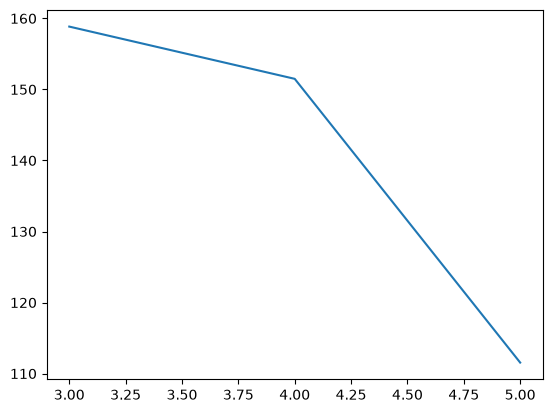

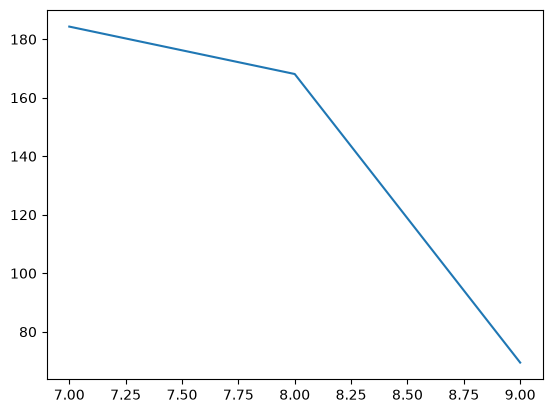

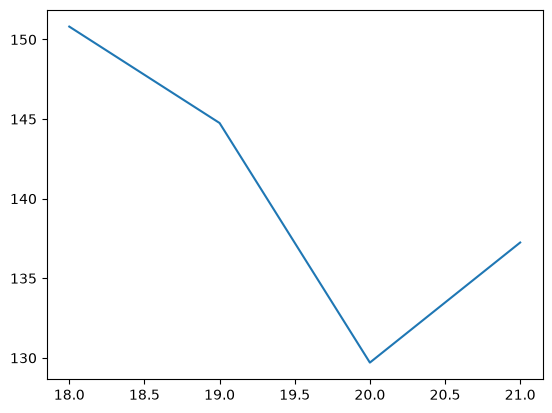

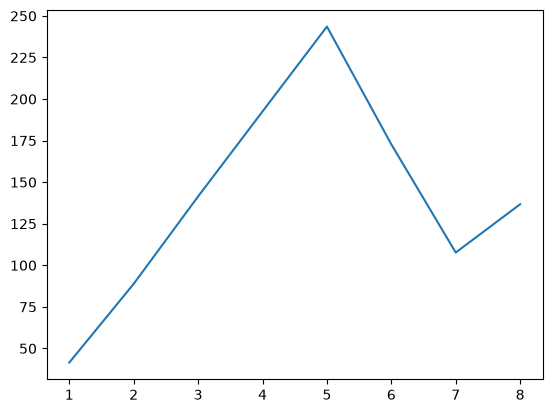

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df_result = pd.read_csv("./results/result_GBPJPY_1789884596.9675603.csv",sep=',')

result_rt_1 = df_result.groupby('Window')['Return'].mean()
result_rt_2 = df_result.groupby('RTC')['Return'].mean()
result_rt_3 = df_result.groupby('CRH')['Return'].mean()
result_rt_4 = df_result.groupby('STH')['Return'].mean()
result_rt_5 = df_result.groupby('TpMultiple')['Return'].mean()

plt.figure(1)
plt.plot(result_rt_1.index, result_rt_1.values)
plt.figure(2)
plt.plot(result_rt_2.index, result_rt_2.values)
plt.figure(3)
plt.plot(result_rt_3.index, result_rt_3.values)
plt.figure(4)
plt.plot(result_rt_4.index, result_rt_4.values)
plt.figure(5)
plt.plot(result_rt_5.index, result_rt_5.values)

plt.show()

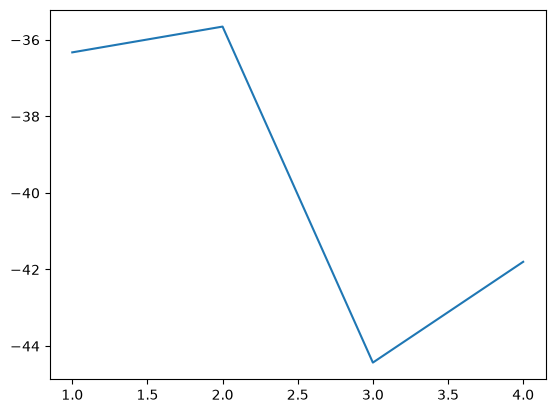

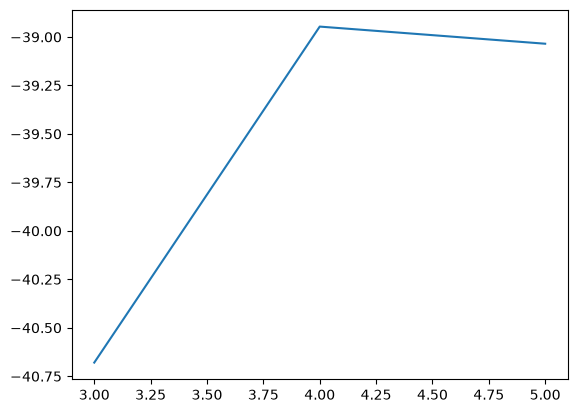

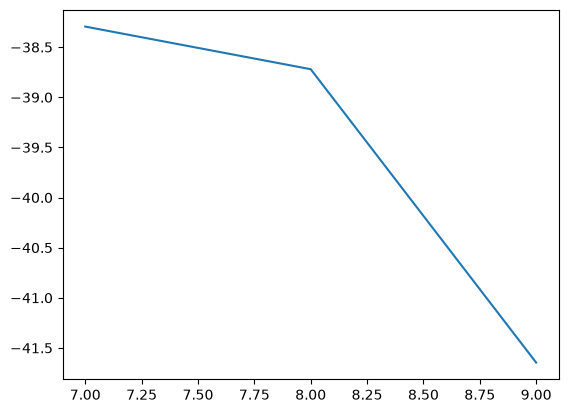

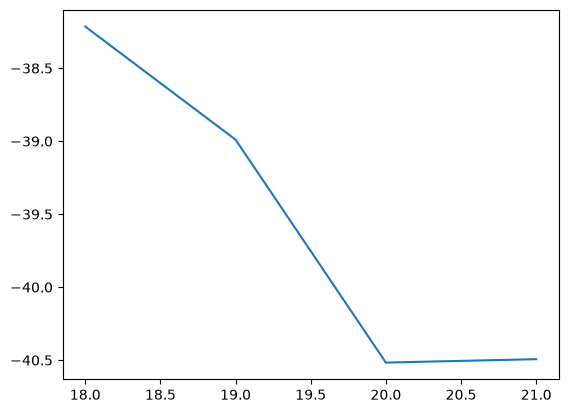

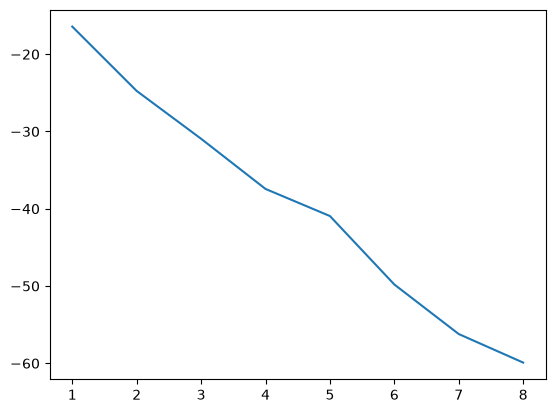

In [19]:
import matplotlib.pyplot as plt

df_result = pd.read_csv("./results/result_GBPJPY_1789884596.9675603.csv",sep=',')

result_rt_1 = df_result.groupby('Window')['MDrawdown'].mean()
result_rt_2 = df_result.groupby('RTC')['MDrawdown'].mean()
result_rt_3 = df_result.groupby('CRH')['MDrawdown'].mean()
result_rt_4 = df_result.groupby('STH')['MDrawdown'].mean()
result_rt_5 = df_result.groupby('TpMultiple')['MDrawdown'].mean()

plt.figure(1)
plt.plot(result_rt_1.index, result_rt_1.values)
plt.figure(2)
plt.plot(result_rt_2.index, result_rt_2.values)
plt.figure(3)
plt.plot(result_rt_3.index, result_rt_3.values)
plt.figure(4)
plt.plot(result_rt_4.index, result_rt_4.values)
plt.figure(5)
plt.plot(result_rt_5.index, result_rt_5.values)

plt.show()

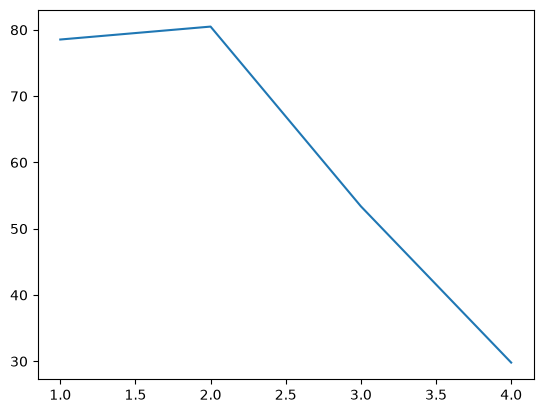

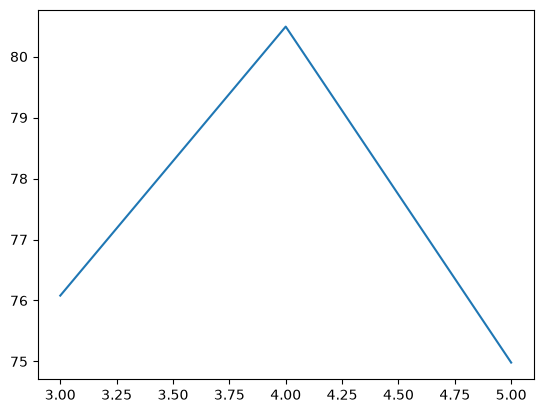

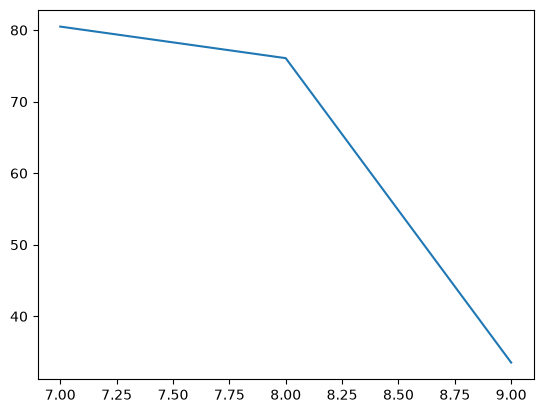

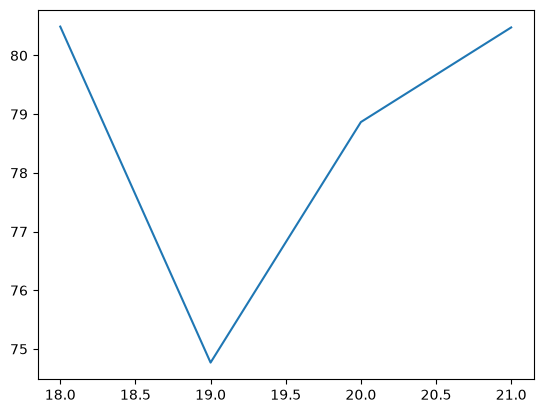

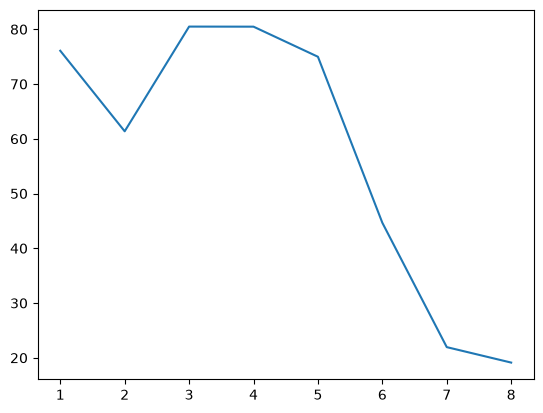

In [37]:
import matplotlib.pyplot as plt

df_result = pd.read_csv("./results/result_USDCAD_1789892972.0949237.csv",sep=',')

result_rt_1 = df_result.groupby('Window')['Return'].max()
result_rt_2 = df_result.groupby('RTC')['Return'].max()
result_rt_3 = df_result.groupby('CRH')['Return'].max()
result_rt_4 = df_result.groupby('STH')['Return'].max()
result_rt_5 = df_result.groupby('TpMultiple')['Return'].max()

plt.figure(1)
plt.plot(result_rt_1.index, result_rt_1.values)
plt.figure(2)
plt.plot(result_rt_2.index, result_rt_2.values)
plt.figure(3)
plt.plot(result_rt_3.index, result_rt_3.values)
plt.figure(4)
plt.plot(result_rt_4.index, result_rt_4.values)
plt.figure(5)
plt.plot(result_rt_5.index, result_rt_5.values)

plt.show()

Start                     2020-01-01 22:00...
End                       2026-09-17 01:00...
Duration                   2450 days 02:00:00
Exposure Time [%]                    47.61996
Equity Final [$]                    59471.886
Equity Peak [$]                     91642.593
Return [%]                          494.71886
Buy & Hold Return [%]                45.09965
Return (Ann.) [%]                    23.88137
Volatility (Ann.) [%]                33.67516
CAGR [%]                             30.44629
Sharpe Ratio                          0.70917
Sortino Ratio                         1.53726
Calmar Ratio                          0.68029
Alpha [%]                           477.12549
Beta                                   0.3901
Max. Drawdown [%]                   -35.10454
Avg. Drawdown [%]                    -2.64437
Max. Drawdown Duration      520 days 03:00:00
Avg. Drawdown Duration       12 days 03:00:00
# Trades                                  544
Win Rate [%]                      

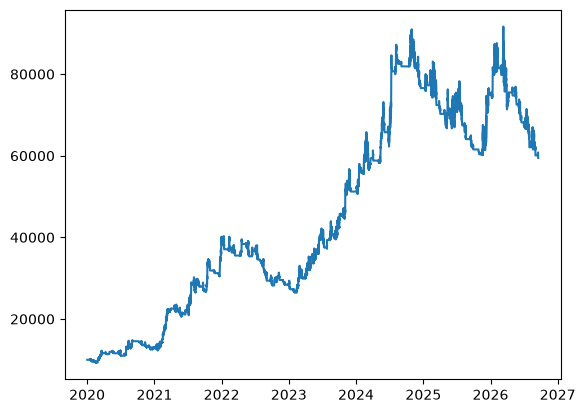

In [ ]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from ta.trend import EMAIndicator
from ta.volatility import AverageTrueRange
from backtesting import Backtest, Strategy

window = 2
global_range_to_consider = 3
global_close_range_hour = 7
global_stop_trade_hour = 18
global_tp_multiple = 5

start_date = '2020-01-01 00:00'
end_date = '2026-9-17 00:00'
pair = 'GBPJPY'
timezone = "Europe/London"

df_d1 = pd.read_csv(f"./Trading Data/{pair}_D1.csv",sep=',', parse_dates=['Date'], index_col='Date')
df_d1 = df_d1.loc[start_date : end_date]

df_result = implement_market_structure_states_strict(df_d1, n=window)

# df['market_state'] = df_result["market_state"]

df_h1 = pd.read_csv(f"./Trading Data/{pair}_H1.csv",sep=',', parse_dates=['Date'], index_col='Date')
df_h1 = df_h1.loc[start_date : end_date]

d1_tf_direction_list = []

for index, row in df_result.iterrows():
    df_by_day = df_h1.loc[f'{index.date()}' : f'{index.date()}']
    for index2, row2 in df_by_day.iterrows():
        d1_tf_direction_list.append(row['market_state'])

df_h1['market_state'] = d1_tf_direction_list

indicator_atr_14 = AverageTrueRange(df_h1['High'], df_h1['Low'], df_h1['Close'], window=14)
df_h1['ATR'] = indicator_atr_14._atr
df_h1.index = pd.to_datetime(df_h1.index, utc=True).tz_convert(timezone)

bt = Backtest(df_h1, OpeningRangeBreakout, margin=0.02, finalize_trades=True)

stats = bt.run()

# print(stats._equity_curve)
print(stats)


plt.figure(1)
plt.plot(stats._equity_curve.index, stats._equity_curve['Equity'])



